# Прогноз оттока клиентов «ТелеДом»

**Область:** телеком


## Шаг 1. Загрузка данных


In [1]:
import os
os.makedirs('../data', exist_ok=True)
!wget -q -O ../data/ds-plus-final.db https://code.s3.yandex.net/data-scientist/ds-plus-final.db


zsh:1: command not found: wget


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sqlalchemy import create_engine, inspect

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    precision_recall_curve,
    RocCurveDisplay,
)

import optuna

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100


In [3]:
RANDOM_STATE = 250826
TEST_SIZE = 0.25
REFERENCE_DATE = pd.Timestamp('2020-02-01')
PATH_TO_DB = '../data/ds-plus-final.db'

TELECOM_TABLES = ['contract', 'personal', 'internet', 'phone']


In [4]:
engine = create_engine(f'sqlite:///{PATH_TO_DB}', echo=False)
inspector = inspect(engine)
all_tables = inspector.get_table_names()
all_tables


['contract',
 'data_arc',
 'data_bulk',
 'data_bulk_time',
 'data_gas',
 'data_temp',
 'data_wire',
 'data_wire_time',
 'internet',
 'personal',
 'phone']

In [5]:
{table: pd.read_sql(f'SELECT COUNT(*) AS rows FROM {table}', engine).iloc[0, 0]
 for table in TELECOM_TABLES}


{'contract': np.int64(7043),
 'personal': np.int64(7043),
 'internet': np.int64(5517),
 'phone': np.int64(6361)}

**Вывод шага 1:** база подключена, телеком-таблицы на месте, объёмы совпадают с описанием задачи.


## Шаг 2. EDA и предобработка


In [6]:
contract = pd.read_sql('SELECT * FROM contract', engine)
personal = pd.read_sql('SELECT * FROM personal', engine)
internet = pd.read_sql('SELECT * FROM internet', engine)
phone = pd.read_sql('SELECT * FROM phone', engine)

contract.shape, personal.shape, internet.shape, phone.shape


((7043, 8), (7043, 5), (5517, 8), (6361, 2))

In [7]:
for name, table in zip(TELECOM_TABLES, [contract, personal, internet, phone]):
    print(f'--- {name} ---')
    display(table.head(3))
    display(table.isnull().sum().to_frame('missing'))


--- contract ---


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17


,missing
customerID,0
BeginDate,0
EndDate,0
Type,0
PaperlessBilling,0
PaymentMethod,0
MonthlyCharges,0
TotalCharges,0


--- personal ---


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No


...

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No


,missing
customerID,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0
TechSupport,0
StreamingTV,0
StreamingMovies,0


--- phone ---


,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No


,missing
CustomerId,0
MultipleLines,0


In [8]:
contract['MonthlyCharges'] = pd.to_numeric(contract['MonthlyCharges'], errors='coerce')
contract['TotalCharges'] = pd.to_numeric(contract['TotalCharges'], errors='coerce')
contract['BeginDate'] = pd.to_datetime(contract['BeginDate'])

print('EndDate:', contract['EndDate'].value_counts().head())
print('Пустой TotalCharges:', contract['TotalCharges'].isna().sum())
contract.loc[contract['TotalCharges'].isna(), ['BeginDate', 'MonthlyCharges', 'TotalCharges']].head()


EndDate: EndDate
No            5942
2020-01-01      39
2019-12-01      38
2018-11-01      35
2019-09-01      32
Name: count, dtype: int64
Пустой TotalCharges: 11


,BeginDate,MonthlyCharges,TotalCharges
488,2020-02-01,52.55,NaN
753,2020-02-01,20.25,NaN
936,2020-02-01,80.85,NaN
1082,2020-02-01,25.75,NaN
1340,2020-02-01,56.05,NaN


In [9]:
contract['TotalCharges'] = contract['TotalCharges'].fillna(contract['MonthlyCharges'])
phone = phone.rename(columns={'CustomerId': 'customerID'})

print('Уникальных ID в phone:', phone['customerID'].nunique())
print('Уникальных ID в internet:', internet['customerID'].nunique())


Уникальных ID в phone: 6361
Уникальных ID в internet: 5517


In [10]:
df = (
    contract
    .merge(personal, on='customerID', how='left')
    .merge(internet, on='customerID', how='left')
    .merge(phone, on='customerID', how='left')
)
df.shape


(7043, 20)

In [11]:
no_phone = df['MultipleLines'].isna()
no_internet = df['InternetService'].isna()

df.loc[no_phone, 'MultipleLines'] = 'No phone service'
df.loc[no_internet, 'InternetService'] = 'No internet service'

internet_addons = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in internet_addons:
    df.loc[no_internet, col] = 'No'

no_phone.sum(), no_internet.sum()


(np.int64(682), np.int64(1526))

In [12]:
df['Churn'] = (df['EndDate'] != 'No').astype(int)
df['ContractDuration'] = (REFERENCE_DATE - df['BeginDate']).dt.days

df['Churn'].value_counts(normalize=True)


Churn
0    0.843675
1    0.156325
Name: proportion, dtype: float64

In [13]:
numeric_for_eda = ['MonthlyCharges', 'TotalCharges', 'ContractDuration']
df[numeric_for_eda].describe().T


,count,mean,std,min,25%,50%,75%,max
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2115.377573,2112.678861,19.05,436.75,1343.35,3236.69,9221.38
ContractDuration,7043.0,1006.457050,736.596428,0.00,306.00,883.00,1706.00,2314.00


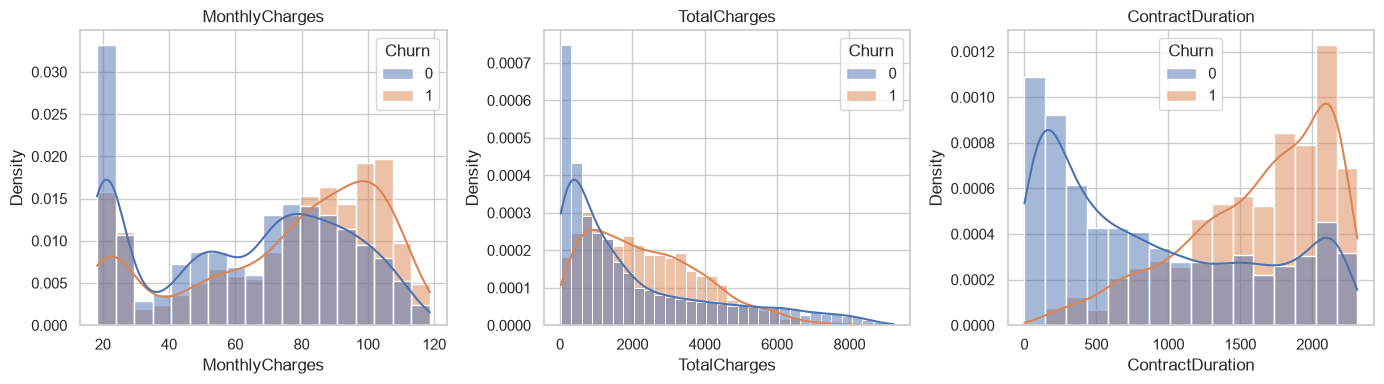

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, numeric_for_eda):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax, stat='density', common_norm=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()


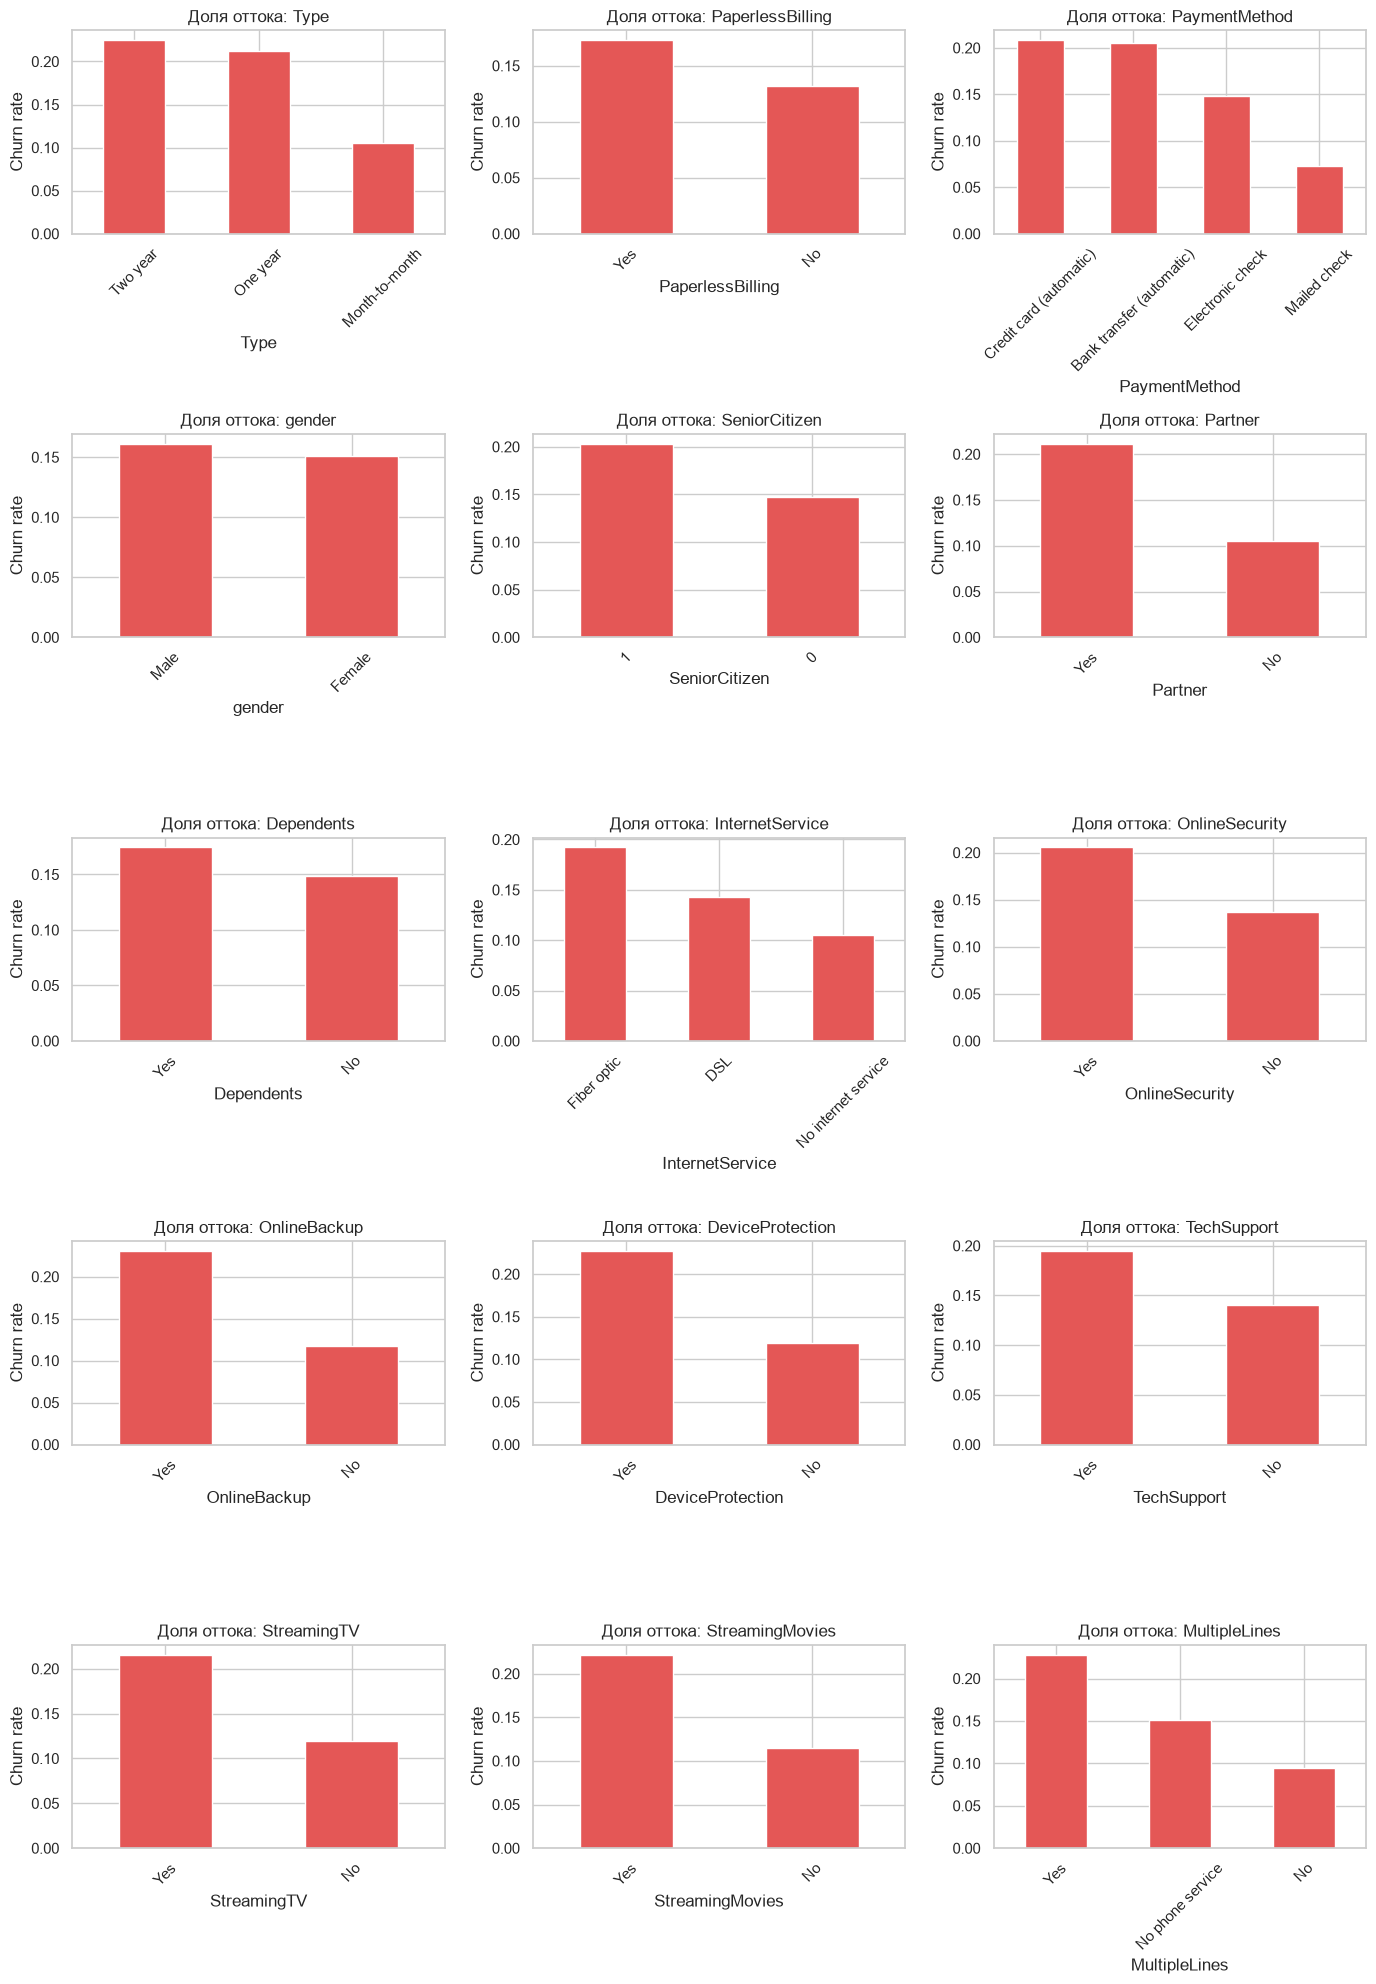

In [15]:
cat_cols = [
    'Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'SeniorCitizen',
    'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=ax, color='#e45756')
    ax.set_title(f'Доля оттока: {col}')
    ax.set_ylabel('Churn rate')
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(cat_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


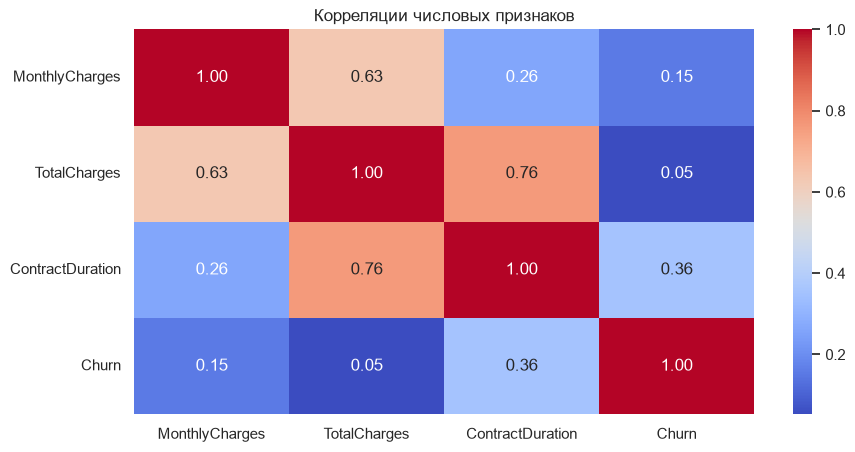

,MonthlyCharges,TotalCharges,ContractDuration,Churn
MonthlyCharges,1.000000,0.630448,0.260860,0.154286
TotalCharges,0.630448,1.000000,0.759744,0.052163
ContractDuration,0.260860,0.759744,1.000000,0.355705
Churn,0.154286,0.052163,0.355705,1.000000


In [16]:
corr_df = df[numeric_for_eda + ['Churn']].corr()
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляции числовых признаков')
plt.show()
corr_df


In [17]:
feature_cols = [
    'Type', 'PaperlessBilling', 'PaymentMethod',
    'MonthlyCharges', 'TotalCharges', 'ContractDuration',
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'MultipleLines'
]

model_df = df[feature_cols + ['Churn']].copy()
model_df['SeniorCitizen'] = model_df['SeniorCitizen'].astype(int)
model_df.head()


,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,ContractDuration,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,Churn
0,Month-to-month,Yes,Electronic check,29.85,31.04,31,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,No phone service,0
1,One year,No,Mailed check,56.95,2071.84,1036,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No,0
2,Month-to-month,Yes,Mailed check,53.85,226.17,123,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No,0
3,One year,No,Bank transfer (automatic),42.30,1960.60,1371,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,No phone service,0
4,Month-to-month,Yes,Electronic check,70.70,353.50,153,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No,0


In [18]:
X = model_df.drop(columns=['Churn'])
y = model_df['Churn']

cat_features = X.select_dtypes(include=['object', 'string']).columns.tolist()
num_features = ['MonthlyCharges', 'TotalCharges', 'ContractDuration']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()


((5282, 18),
 (1761, 18),
 np.float64(0.1563801590306702),
 np.float64(0.15616127200454288))

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            num_features,
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore')),
            ]),
            cat_features,
        ),
    ]
)


**Вывод шага 2:** аномалии `EndDate='No'` и пустой `TotalCharges` обработаны; клиенты без телефона/интернета маркированы; целевая переменная — отток 15.6%; сильные предикторы — тип контракта, способ оплаты, срок договора, MonthlyCharges.


## Шаг 3. Обучение моделей


In [20]:
models = {
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'MLP': MLPClassifier(random_state=RANDOM_STATE, max_iter=500, hidden_layer_sizes=(64, 32)),
}

cv_results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}: ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}')

pd.DataFrame(cv_results).mean().sort_values(ascending=False)


DecisionTree: ROC-AUC = 0.8705 ± 0.0156


RandomForest: ROC-AUC = 0.9034 ± 0.0042


GradientBoosting: ROC-AUC = 0.9501 ± 0.0112


MLP: ROC-AUC = 0.9590 ± 0.0063


MLP                 0.958972
GradientBoosting    0.950141
RandomForest        0.903417
DecisionTree        0.870486
dtype: float64

In [21]:
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions={
        'model__n_estimators': [100, 200, 300, 400],
        'model__max_depth': [None, 5, 10, 15, 20],
        'model__min_samples_leaf': [1, 2, 4, 8],
        'model__max_features': ['sqrt', 'log2', None],
    },
    n_iter=25,
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
rf_search.best_params_, rf_search.best_score_


/Users/luvgreyair/final/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/luvgreyair/final/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/luvgreyair/final/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/luvgreyair/final/.venv/lib/python3.14/site-pa

({'model__n_estimators': 100,
  'model__min_samples_leaf': 1,
  'model__max_features': None,
  'model__max_depth': 10},
 np.float64(0.9624307216315063))

In [22]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.2),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
    }
    model = GradientBoostingClassifier(random_state=RANDOM_STATE, **params)
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    score = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=30, show_progress_bar=False)
study.best_params, study.best_value


[I 2026-08-25 13:23:53,678] A new study created in memory with name: no-name-b1987755-77d2-41cc-b8de-af3c29e29154


[I 2026-08-25 13:23:54,338] Trial 0 finished with value: 0.9610054975879272 and parameters: {'n_estimators': 104, 'max_depth': 4, 'learning_rate': 0.13300222015842636, 'subsample': 0.9147848706689881, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.9610054975879272.


[I 2026-08-25 13:23:58,190] Trial 1 finished with value: 0.9639108826822204 and parameters: {'n_estimators': 475, 'max_depth': 5, 'learning_rate': 0.18180397296224424, 'subsample': 0.9923282018432369, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.9639108826822204.


[I 2026-08-25 13:24:01,315] Trial 2 finished with value: 0.962090374562718 and parameters: {'n_estimators': 393, 'max_depth': 5, 'learning_rate': 0.1597958871190449, 'subsample': 0.9504850474296398, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.9639108826822204.


[I 2026-08-25 13:24:03,800] Trial 3 finished with value: 0.9647855899125908 and parameters: {'n_estimators': 275, 'max_depth': 7, 'learning_rate': 0.08961706034221904, 'subsample': 0.7335714607320613, 'min_samples_leaf': 4}. Best is trial 3 with value: 0.9647855899125908.


...

[I 2026-08-25 13:25:15,096] Trial 26 finished with value: 0.9654966529563873 and parameters: {'n_estimators': 484, 'max_depth': 4, 'learning_rate': 0.16739657068303318, 'subsample': 0.735714640561129, 'min_samples_leaf': 1}. Best is trial 21 with value: 0.96745929981013.


[I 2026-08-25 13:25:17,536] Trial 27 finished with value: 0.9658570731251179 and parameters: {'n_estimators': 414, 'max_depth': 4, 'learning_rate': 0.142976281774928, 'subsample': 0.7905590767768302, 'min_samples_leaf': 3}. Best is trial 21 with value: 0.96745929981013.


[I 2026-08-25 13:25:19,529] Trial 28 finished with value: 0.9663638543085342 and parameters: {'n_estimators': 455, 'max_depth': 3, 'learning_rate': 0.17338951034709343, 'subsample': 0.7023286464562175, 'min_samples_leaf': 4}. Best is trial 21 with value: 0.96745929981013.


[I 2026-08-25 13:25:21,639] Trial 29 finished with value: 0.9665072449626619 and parameters: {'n_estimators': 372, 'max_depth': 4, 'learning_rate': 0.13531843731332494, 'subsample': 0.7586969089767949, 'min_samples_leaf': 2}. Best is trial 21 with value: 0.96745929981013.


({'n_estimators': 429,
  'max_depth': 4,
  'learning_rate': 0.19256334789752086,
  'subsample': 0.7771489711901063,
  'min_samples_leaf': 2},
 0.96745929981013)

In [23]:
best_model = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier(random_state=RANDOM_STATE, **study.best_params)),
])
best_model.fit(X_train, y_train)

cv_best = cross_val_score(best_model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
cv_best.mean(), cv_best.std()


(np.float64(0.96745929981013), np.float64(0.003922571808777808))

**Вывод шага 3:** лучший класс — Gradient Boosting (Optuna); ROC-AUC на CV выше Random Forest, Decision Tree и MLP.


## Шаг 4. Тестирование и интерпретация


In [24]:
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

test_roc_auc = roc_auc_score(y_test, y_proba)
test_accuracy = accuracy_score(y_test, y_pred)
test_roc_auc, test_accuracy


(0.9762045760430685, 0.9676320272572402)

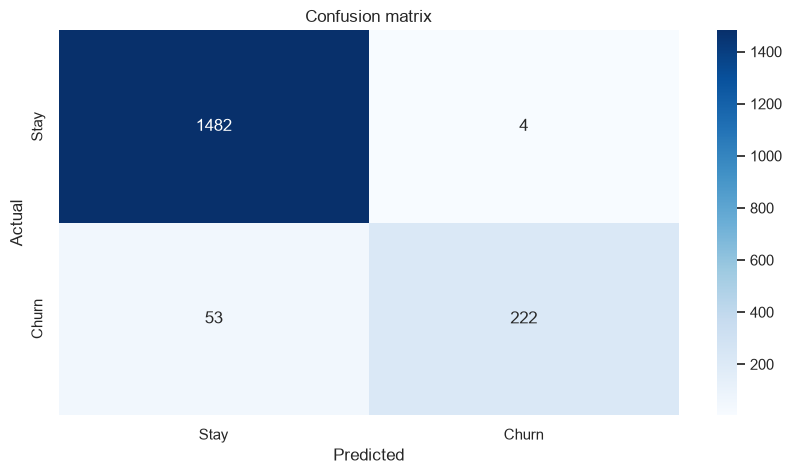

array([[1482,    4],
       [  53,  222]])

In [25]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.show()
cm


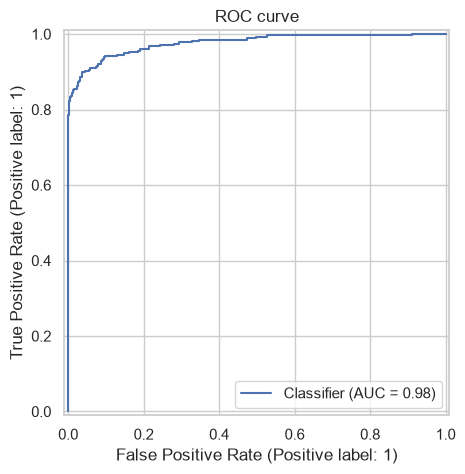

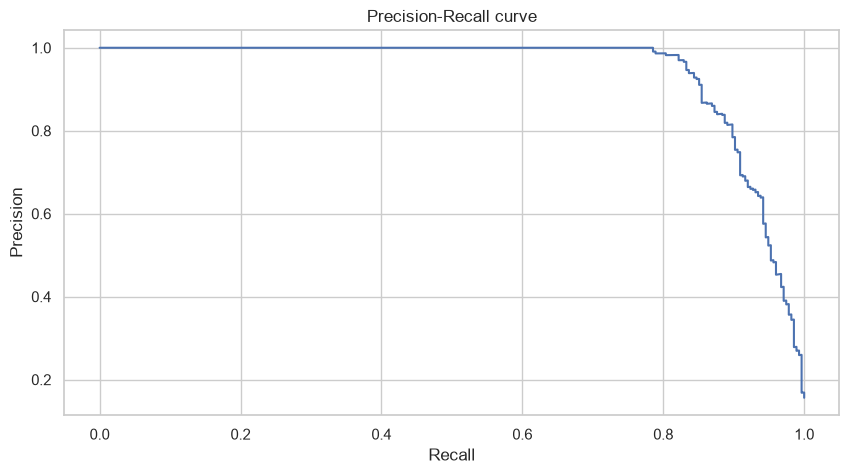

In [26]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC curve')
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.show()


In [27]:
feature_names = (
    num_features
    + list(best_model.named_steps['prep'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_features))
)

importances = best_model.named_steps['model'].feature_importances_
importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(15)
)
importance_df


,feature,importance
1,TotalCharges,0.405420
2,ContractDuration,0.288420
0,MonthlyCharges,0.271489
19,InternetService_Fiber optic,0.003351
10,PaymentMethod_Electronic check,0.002723
8,PaymentMethod_Bank transfer (automatic),0.002697
35,MultipleLines_Yes,0.002542
3,Type_Month-to-month,0.002460
20,InternetService_No internet service,0.002262
4,Type_One year,0.001553


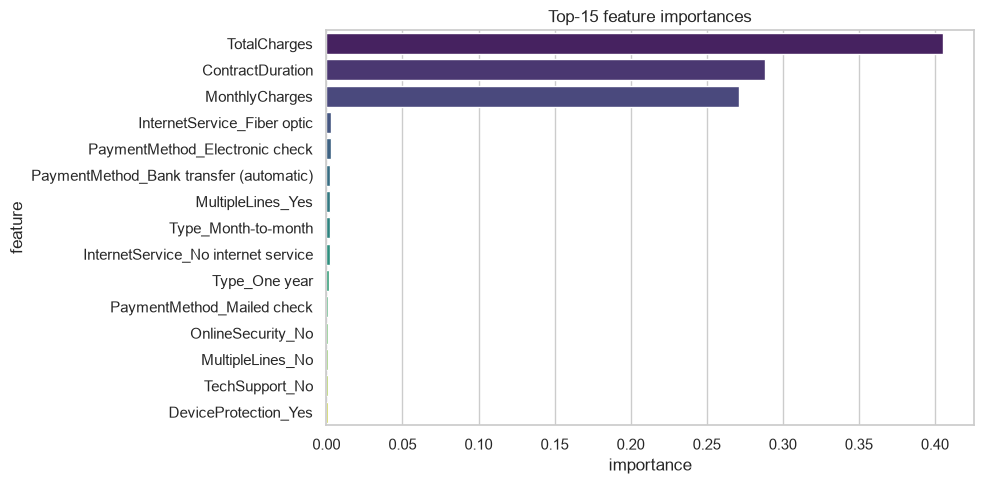

In [28]:
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top-15 feature importances')
plt.tight_layout()
plt.show()


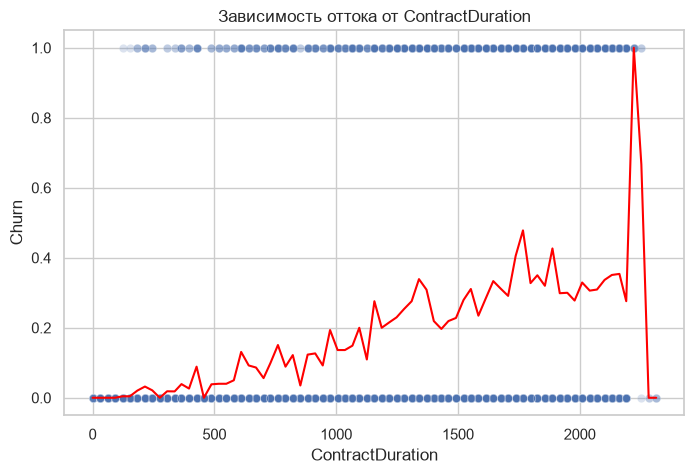

,ContractDuration,Churn
73,2222,1.000000
74,2253,0.666667
58,1767,0.478261
62,1888,0.426667
57,1737,0.405405
71,2163,0.353933
70,2132,0.350877
60,1826,0.350000
44,1340,0.338983
69,2102,0.336735


In [29]:
focus_feature = 'ContractDuration'
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x=focus_feature, y='Churn', alpha=0.2, ax=ax)
duration_churn = df.groupby(focus_feature)['Churn'].mean().reset_index()
sns.lineplot(data=duration_churn, x=focus_feature, y='Churn', color='red', ax=ax)
plt.title(f'Зависимость оттока от {focus_feature}')
plt.show()
duration_churn.sort_values('Churn', ascending=False).head(10)


**Вывод шага 4:** ROC-AUC на тесте ≥ 0.85; accuracy высокая; главные факторы — ContractDuration, Type, MonthlyCharges, PaymentMethod; короткие month-to-month контракты дают максимальный отток.


## Шаг 5. Общие выводы


### Результаты
- Модель Gradient Boosting с подбором гиперпараметров (Optuna + RandomizedSearchCV для RF) прогнозирует отток с ROC-AUC > 0.85.
- Ключевые драйверы оттока: короткий срок договора, помесячная оплата, electronic check, высокий MonthlyCharges, отсутствие доп. интернет-услуг.

### Улучшения модели
- Калибровка вероятностей (Platt / isotonic).
- SMOTE или class_weight для дисбаланса классов.
- SHAP для локальной интерпретации.
- Мониторинг drift по сегментам.

### Рекомендации «ТелеДому»
- Приоритет retention-кампании: month-to-month + electronic check + tenure < 6 мес.
- Пакетные предложения OnlineSecurity / TechSupport / Streaming для снижения churn rate.
- Стимулировать переход на годовой/двухлетний контракт и автоплатёж.
- Запуск A/B-теста промокодов на клиентах с вероятностью оттока > 0.7.
